In [1]:
from pathlib import Path
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df=pd.read_csv("../data/3_processed/paquet_phrases_lemm.csv") # Chargement du DataFrame nettoyé à partir du fichier CSV

In [3]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...


In [52]:
vectorizer = TfidfVectorizer( 
    min_df=3,
    max_df=0.8
    )

X = vectorizer.fit_transform(df["phrases_lemm"])  
#Appliquer le TF-IDF vectorizer sur les segments de texte nettoyés pour obtenir une matrice de caractéristiques (termes pondérés par leur importance dans les segments).

X.shape

(5327, 11640)

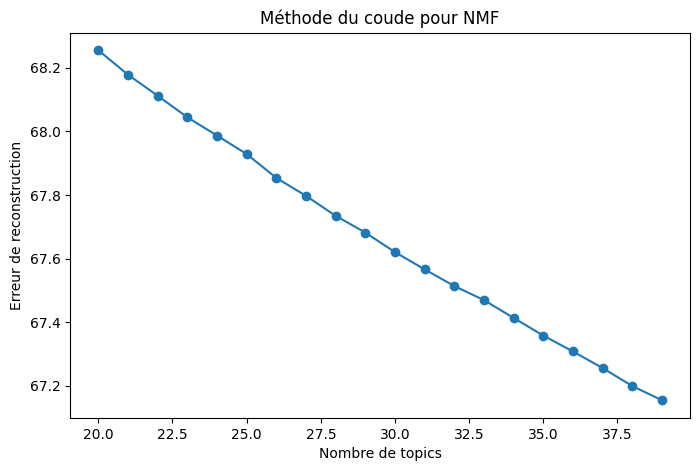

In [53]:
errors = []
k_values = range(20, 40)

for k in k_values:
    nmf = NMF(
        n_components=k,
        random_state=42,
        init="nndsvda",
        max_iter=500
    )
    
    nmf.fit(X)
    errors.append(nmf.reconstruction_err_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker="o")
plt.xlabel("Nombre de topics")
plt.ylabel("Erreur de reconstruction")
plt.title("Méthode du coude pour NMF")
plt.show()

In [54]:
def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")



feature_names = vectorizer.get_feature_names_out()

#for k in  [8, 10, 12, 15, 18 ]: # On teste différents nombres de topics (de 5 à 15) pour trouver le nombre optimal de topics pour notre analyse.
    
    #print(f"\n NMF avec {k} topics") 
nmf = NMF(n_components=28, 
          random_state=42,
          init="nndsvda",
          solver="cd",
          max_iter=1000,
          
            )
W = nmf.fit_transform(X)
afficher_topics(nmf, feature_names)

print("Erreur :", nmf.reconstruction_err_)

Topic 1 : amour | femme | amant | cœur | vie | jour | tendresse | pensée | soir | bonheur
Topic 2 : travail | vie | peuple | bonheur | œuvre | usine | justice | humanité | monde | terre
Topic 3 : arbre | soleil | eau | herbe | ciel | jardin | ombre | terre | horizon | branche
Topic 4 : empereur | ministre | affaire | député | président | journal | préfet | ami | politique | lettre
Topic 5 : abbé | prêtre | curé | église | jardin | trouche | soutane | sous | préfecture | évêque
Topic 6 : bête | coup | vrai | bon | terre | femme | chose | air | poing | cochon
Topic 7 : mort | oeil | main | voix | sang | larme | tête | bras | face | visage
Topic 8 : franc | argent | somme | billet | mois | chiffre | fortune | sou | affaire | million
Topic 9 : monsieur | dame | porte | vou | bon | air | voix | femme | domestique | main
Topic 10 : rue | boutique | quartier | trottoir | maison | boulevard | ville | place | chaussée | marchand
Topic 11 : père | fils | famille | vieux | fille | mère | mort | m

In [55]:
W_norm = W / W.sum(axis=1, keepdims=True)

df["topic_dominant"] = W_norm.argmax(axis=1)
df["poids_topic"] = W_norm.max(axis=1)

In [56]:
df

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm,topic_dominant,poids_topic
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...,19,0.214654
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...,24,0.265577
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...,19,0.175886
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...,23,0.162846
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...,10,0.160237
...,...,...,...,...,...,...
5322,1894_1_Lourdes._clean.txt,193,"Le diable dans cette vie si pure, dans cette â...",diable vie pur âme péché coup souffrance pardo...,20,0.478421
5323,1894_1_Lourdes._clean.txt,194,Des milliers de pèlerins avaient beau se rendr...,millier pèlerin beau année peuple tentative ré...,20,0.387352
5324,1894_1_Lourdes._clean.txt,195,"Elle était sa maîtresse souveraine, elle le te...",maîtresse souverain milieu obscurité avortemen...,1,0.440497
5325,1894_1_Lourdes._clean.txt,196,Et n’aurait-il pas fallu la venue d’un nouveau...,venue sauveur souffle prodigieux volée cloche ...,1,0.363503


In [57]:
for topic in sorted(df["topic_dominant"].unique()):
    print(f"\n TOPIC {topic+1} ")
    subset = (
        df[df["topic_dominant"] == topic] 
        .sort_values("poids_topic", ascending=False)
        .head(5)
    )
    for _, row in subset.iterrows():
        print(f"\nTitre : {row['nom_fichier']} | Poids : {row['poids_topic']:.4f}")
        print(row["phrases_paquet"][:500])


 TOPIC 1 

Titre : 1866_Le_voeu_d_une_morte._clean.txt | Poids : 0.4787
Lorsque Daniel ne fut plus là, Georges, sans se l’avouer, respira plus librement. Il se trouvait seul avec son amour, seul avec Jeanne; et il lui semblait qu’il était à la fois son amant et son frère, maintenant qu’elle n’avait plus personne qui veillât sur elle. Il prit un plaisir délicat à ne pas aller tout de suite se jeter à ses genoux: pendant deux jours, il se défendit de la voir, il rêva les premières paroles qu’il lui adresserait et le premier regard qu’elle aurait pour lui. L’entrevue f

Titre : 1866_Le_voeu_d_une_morte._clean.txt | Poids : 0.4706
Il ne savait quel en serait l’effet. Il espérait. Daniel écrivait à Jeanne: Pardonnez-moi, je ne puis me taire, il faut que je vide mon cœur. Vous ne me connaîtrez jamais. C’est ici l’aveu d’un inconnu qui est lâche, qui n’a pas le courage de vous aimer sans vous le dire. Je ne demande rien, je souhaite seulement que vous lisiez cette lettre afin que vous sachie

In [58]:
noms_topics_nmf = {
    1: "L’amour et les sentiments",  # ok
    2: "Le travail et le peuple",  # ok
    3: "La nature et le paysage",  # ok
    4: "Le pouvoir politique et les affaires publiques",  # ok
    5: "Le clergé et la paroisse",  # ok
    6: "La terre, les animaux et le monde paysan",  # à revoir et à préciser les mots-clés
    7: "Le corps et la souffrance",  # à revoir le thème
    8: "L’argent et la fortune",  # ok
    9: "Les conversations et les scènes domestiques",  # voir avec les phrases
    10: "Le quartier et la ville",  # ok
    11: "La famille et les relations familiales",  # à revoir et à préciser les mots-clés
    12: "Le monde ferroviaire",  # ok
    13: "Les liens familiaux, l’écriture et les proches",  # à revoir et à préciser les mots-clés
    14: "Le pouvoir religieux",  # ok
    15: "L’école et l’instruction",  # ok
    16: "La chambre et le mobilier",  # ok
    17: "Le monde de la mode et des vêtements",  # ok
    18: "La guerre, les soldats et l’armée",  # ok
    19: "Le désir, le mariage et les relations amoureuses",  # à revoir et à préciser les mots-clés, bruit dans le thème
    20: "Le monde médical et la santé",  # ok
    21: "Le miracle, le pèlerinage et la religion",  # ok
    22: "Le monde artistique et la peinture",  # ok
    23: "La famille maternelle",  # à revoir et à préciser les mots-clés
    24: "L’insurrection et la révolution",  # ok
    25: "Les couleurs et la toilette",  # ok
    26: "Le salon, l’aristocratie et les scènes mondaines",  # ok
    27: "Le monde ouvrier et la mine",  # ok
    28: "La table et les repas"  # ok
}

In [59]:
df["nom_topic"] = df["topic_dominant"].map(noms_topics_nmf)

In [60]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm,topic_dominant,poids_topic,nom_topic
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...,19,0.214654,"Le désir, le mariage et les relations amoureuses"
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...,24,0.265577,L’insurrection et la révolution
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...,19,0.175886,"Le désir, le mariage et les relations amoureuses"
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...,23,0.162846,La famille maternelle
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...,10,0.160237,Le quartier et la ville


In [61]:
W = nmf.fit_transform(X)
H = nmf.components_

df["topic_dominant"] = W.argmax(axis=1) + 1
df["score_topic_dominant"] = W.max(axis=1)

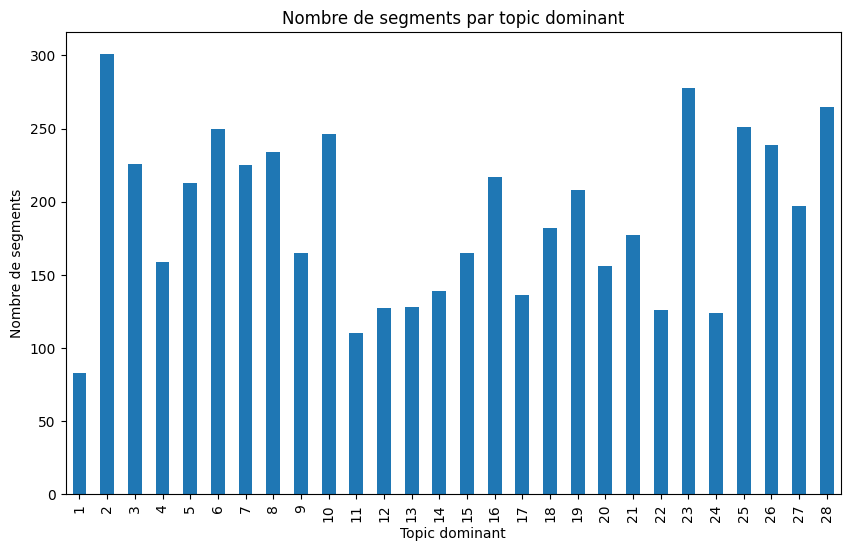

In [62]:
nb_segments = df["topic_dominant"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
nb_segments.plot(kind="bar")

plt.title("Nombre de segments par topic dominant")
plt.xlabel("Topic dominant")
plt.ylabel("Nombre de segments")
plt.show()

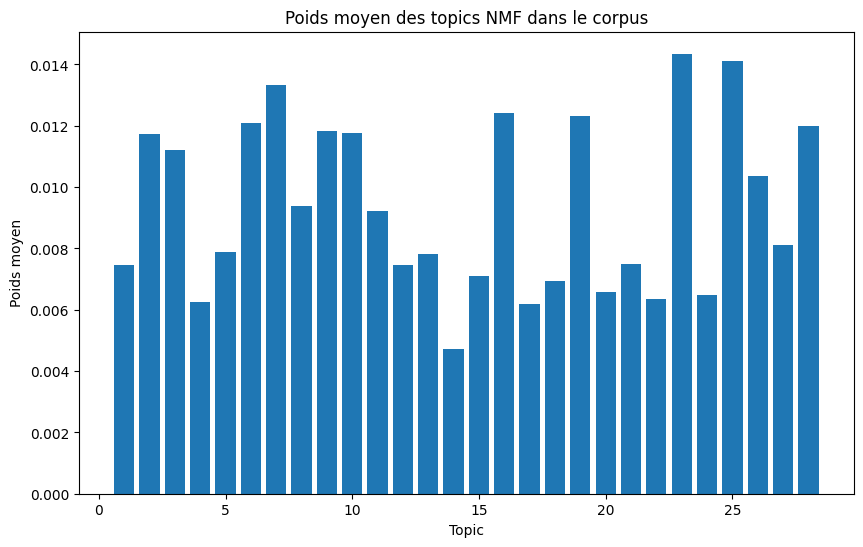

In [63]:
topic_weights = W.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(topic_weights) + 1), topic_weights)

plt.title("Poids moyen des topics NMF dans le corpus")
plt.xlabel("Topic")
plt.ylabel("Poids moyen")
plt.show()

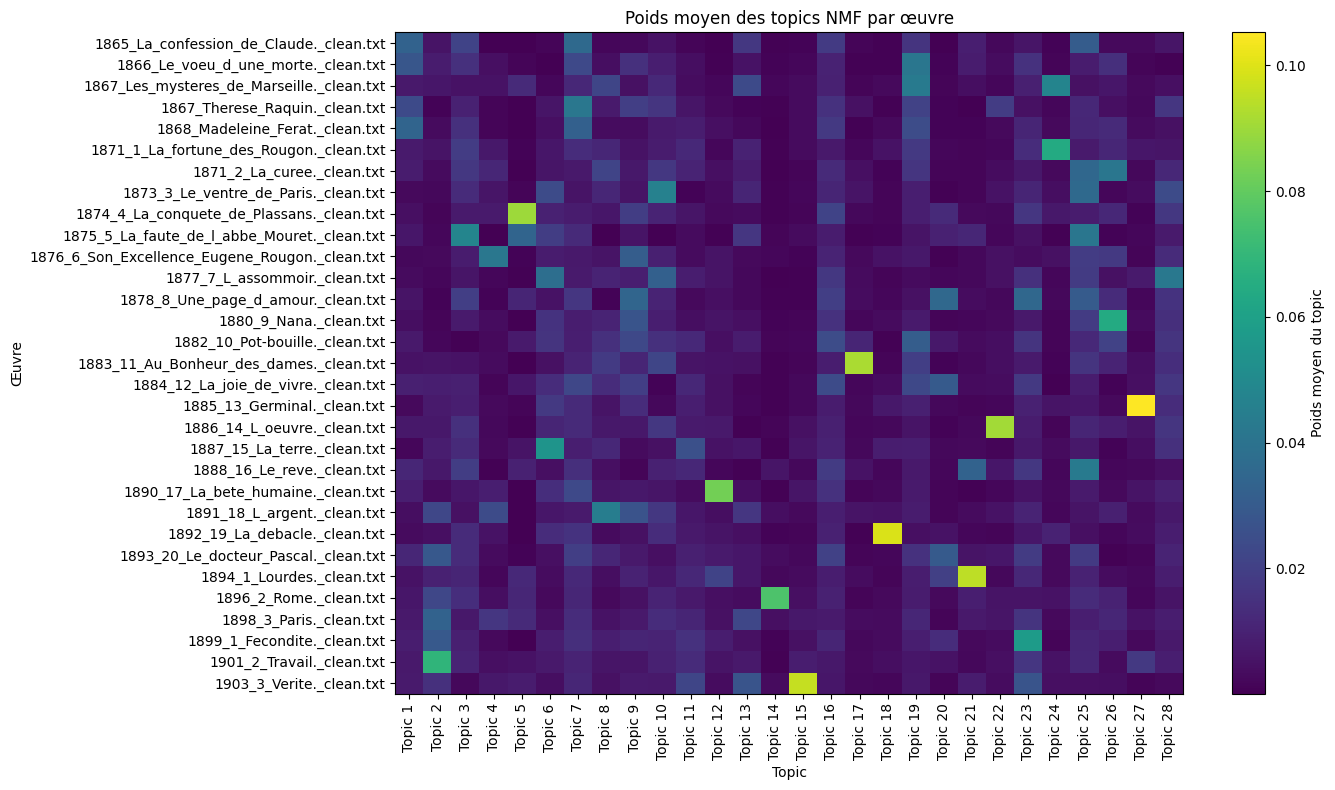

In [64]:
topics_df = pd.DataFrame(
    W,
    columns=[f"Topic {i+1}" for i in range(W.shape[1])]
)

topics_df["nom_fichier"] = df["nom_fichier"].values

table_topics = topics_df.groupby("nom_fichier").mean()

plt.figure(figsize=(14, 8))
plt.imshow(table_topics, aspect="auto")

plt.xticks(range(len(table_topics.columns)), table_topics.columns, rotation=90)
plt.yticks(range(len(table_topics.index)), table_topics.index)

plt.title("Poids moyen des topics NMF par œuvre")
plt.xlabel("Topic")
plt.ylabel("Œuvre")
plt.colorbar(label="Poids moyen du topic")
plt.tight_layout()
plt.show()